## MLP From Scratch

In this notebook we will implement an MLP with two layers and calculate the gradients by hand. Normally, we would need to have the code for backpropagation but creating a backprop engine is a future project so this is the only way I figured I could implement an MLP for now. 

A Neural Network could be represented in $k$ matrices, where $k$ is the depth of your network, and some non-linear activation functions. The implementation below is guranteed to not be optimal (unless I decide to revisit this notebook and make it so) since its purpose is mainly as a learning exercise for me. 

We are going to work on the XOR problem that a logistic regression model can not solve to demonstrate the prowess of Neural Networks. The graph for the 2D XOR problem will be below if you are unfamiliar.

The output of our network will be a probability of the network being in one of two classes.

### Math

We need to calculate the gradients for gradient descent, which we will do mostly by hand.

Since the last layer's weights act much the same as the weights in a logistic regression the gradient there will be much the same. 
So $\frac{\partial L}{\partial w^{(2)}} = a^{(1)}(y-\hat{y})$ where $a^{(1)}$ is the output of the activation function from the first layer.

Now we need to calculate $\frac{\partial L}{\partial w^{(1)}}$ . 
We can state $\frac{\partial L}{\partial w^{(1)}} =  \frac{\partial z^{(1)}}{\partial w^{(1)}}\frac{\partial a^{(1)}}{\partial z^{(1)}}\frac{\partial z^{(2)}}{\partial a^{(1)}}\frac{\partial L}{\partial z^{(2)}}$

Let's handle each partial one-by-one:
- $ \frac{\partial z^{(1)}}{\partial w^{(1)}} = x$ i.e. the derivative of $z=wx+b$ 
- The derivative for ReLU is $ReLU'(z) = \begin{cases} 1 & z > 0 \\ 0 & z \le 0 \end{cases}$ so $\frac{\partial a_1^{(1)}}{\partial z^{(1)}} = \begin{cases} 1 & z > 0 \\ 0 & z \le 0 \end{cases}$
- $\frac{\partial z^{(2)}}{\partial a^{(1)}} = w^{(2)}$ 
- $\frac{\partial L}{\partial z^{(2)}} = \hat{y}-y$. This is seen in logistic regression.

So that means our $\frac{\partial L}{\partial w^{(1)}} = \begin{cases} w^{(2)}*x(\hat{y}-y) & z > 0 \\ 0 & z \le 0 \end{cases}$


### Code

Now we can get to coding the network. I am sure I could do a better job with this, but I am happy with a functional result. Keeping up with dimensions of every matrix was a nightmare for me.


In [138]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
rng = np.random.default_rng(seed=42)

In [134]:
class NeuralNet:
    def __init__(self, layer_widths=(8,1), input_dim=2):
        self.weights = []
        self.biases = []
        self.loss_history = []
        self.z1 = None
        self.a1 = None 
        
        prev_width = input_dim
        for width in layer_widths:
            self.weights.append(rng.standard_normal((prev_width,width)))
            self.biases.append(rng.standard_normal((1,width)))
            prev_width = width
            
    def _relu(self,matrix):
        return np.maximum(0, matrix)
    
    def _sigmoid(self,matrix):
        return 1 / (1+ np.exp(-matrix)) 
    
    def _gradient_w2(self,error):
        return np.sum(self.a1 * (error), axis=0) / len(error)
    
    def _gradient_w1(self, X, error):
        temp = self.weights[1].T * error * (self.z1 > 0)
        return X.T @ temp / len(error)
    
    def _gradient_b2(self,error):
        return np.mean(error, keepdims=True)
    
    def _gradient_b1(self,error):
        return np.mean(self.weights[1].T * error, axis=0,keepdims=True)
    
    def _BCE(self,Y_predict,Y):
        return -1 * np.mean(Y * np.log(Y_predict) + (1-Y) * np.log(1-Y_predict))
        
    def train(self, X, Y, alpha, num_epochs):
        
        for _ in range(num_epochs):
            y_predict = self.forward(X)
            self.loss_history.append(self._BCE(y_predict,Y))
            error = y_predict - Y 
            self.weights[0] -= alpha * self._gradient_w1(X, error)
            self.weights[1] -= alpha * self._gradient_w2(error).reshape(-1,1)
            self.biases[0] -= alpha * self._gradient_b1(error)
            self.biases[1] -= alpha * self._gradient_b2(error)
            
    
    def forward(self,input):
        z1 = input @ self.weights[0] + self.biases[0]
        self.z1 = z1
        a1 = self._relu(z1)
        self.a1 = a1
        z2 = a1 @ self.weights[1] + self.biases[1]
        
        return self._sigmoid(z2)
            

### XOR
Here we will create our data for the XOR problem which as we can see divides our plane into 4 distinct sections. 

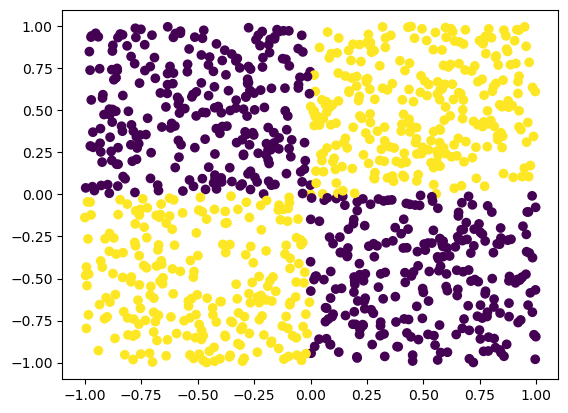

In [135]:
N = 1000
X = rng.uniform(-1,1,(N,2))
Y = np.zeros((N,1))
Y[X[:,0] * X[:,1] > 0] = 1

plt.scatter(X[:,0],X[:,1], c=Y)

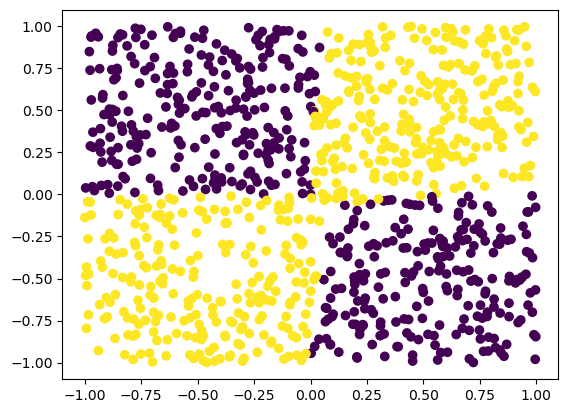

In [161]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size = 0.8)

nn = NeuralNet()
nn.train(X_train,Y_train,0.01,20000)
predictions = np.round(nn.forward(X))

plt.scatter(X[:,0],X[:,1], c=predictions)

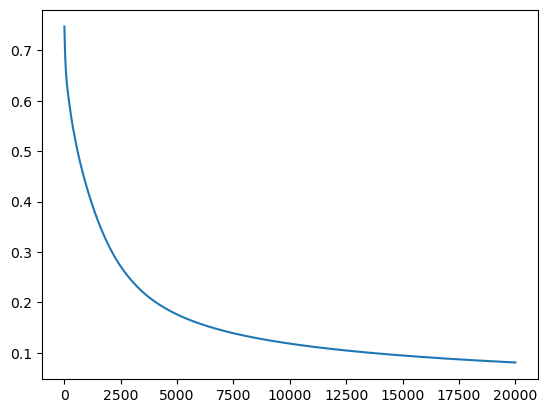

In [162]:
plt.plot(nn.loss_history)